In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import numpy as np
import matplotlib.pyplot as plt

def E_wst_udrop_single_exp(m):
    return -0.18*m + 4.8

def E_wst_lbg_dropout(m_i, D_zu, D_zx, E_wst_udrop_single_exp, dropout_band = 'u'):
    """
    Parameters:
        m_i : float
            Input magnitude
        D_zu : float
            Growth factor D(z_u)
        D_zg : float
            Growth factor D(z_g)
        E_wst_udrop : function
            Function that takes magnitude and returns E_WST^udrop

    Returns:
        float : E_WST^drop
    """
    if not dropout_band == 'u':
        ratio = D_zu / D_zx
        shifted_m = m_i -5 * np.log10(ratio)
    else:
        ratio=1
        shifted_m = m_i
    
    return (ratio ** 2) * E_wst_udrop_single_exp(shifted_m)


def E_piecewise(m, E1_func, p_min):
    m = np.array(m)

    # Base efficiency
    E1 = E1_func(m)

    # Recursive construction
    E2 = E1 + np.sqrt(2)*E1 - np.sqrt(2)*(E1**2)
    E3 = E2 + np.sqrt(3)*E1 - np.sqrt(3)*E2*E1

    # Find thresholds numerically
    m1 = m[np.argmin(np.abs(E1 - p_min))]
    m2 = m[np.argmin(np.abs(E2 - p_min))]

    # Piecewise: 1 → 2 → 3 exposures
    E = np.where(m < m1, E1,
        np.where(m < m2, E2, E3)
    )

    return E, m1, m2

def n_pass(m, E1_func, m1, m2):
    """
    Compute <n_pass(m)> consistently with the exposure model.
    
    Parameters:
        m : array-like
        E1_func : function (single-exposure efficiency)
        m1, m2 : thresholds
    
    Returns:
        array-like
    """
    m = np.array(m)

    # Single-exposure efficiency
    E1 = E1_func(m)

    n = np.where(m < m1, 1,
        np.where(m < m2,
            1 + (1 - E1),
            1 + (1 - E1) + (1 - E1)*(1 - np.sqrt(2)*E1)
        )
    )

    return n

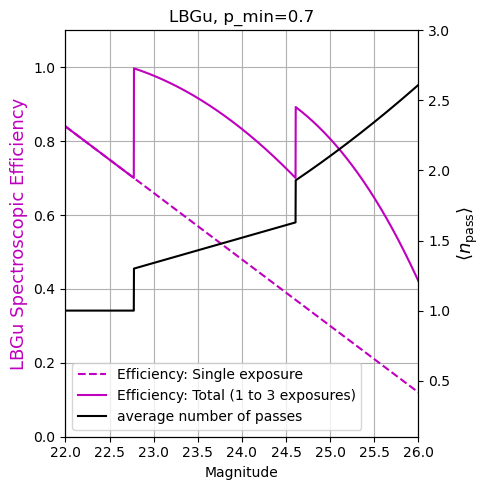

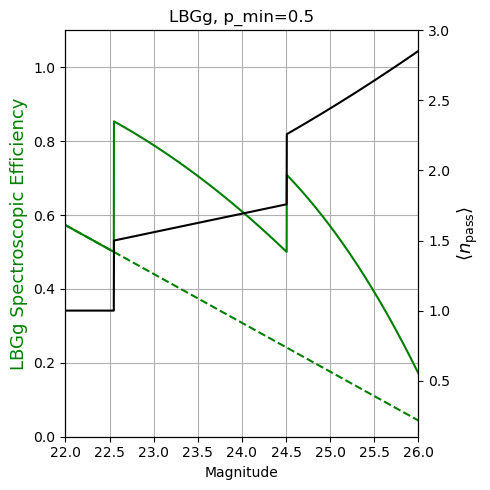

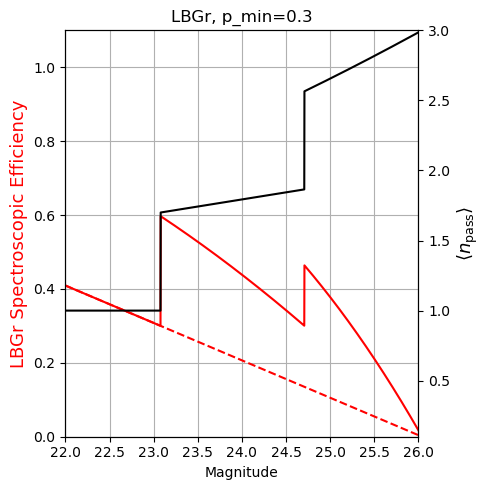

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Magnitude range
m_vals = np.linspace(19., 26, 3400)

color = ['m', 'g', 'r']

p_min_list = [0.7, 0.5, 0.3]
Dz = [6,7,8]

for i, detection_band in enumerate(['u', 'g', 'r']):

    p_min = p_min_list[i]

    def E_single_exp_fct(m):
        return E_wst_lbg_dropout(m, Dz[0], Dz[i], E_wst_udrop_single_exp, dropout_band = detection_band)
    
    E_vals, m1, m2 = E_piecewise(m_vals, E_single_exp_fct, p_min)
    n_vals = n_pass(m_vals, E_single_exp_fct, m1, m2)
    
    # Create figure
    fig, ax1 = plt.subplots(figsize=(5,5))
    ax1.set_title(f"LBG{detection_band}, p_min={p_min}")
    # --- Left axis: Efficiency ---
    ax1.plot(m_vals, E_single_exp_fct(m_vals), '--'+color[i], label="Efficiency: Single exposure")
    ax1.plot(m_vals, E_vals, color=color[i],  label="Efficiency: Total (1 to 3 exposures)")
    
    ax1.set_xlabel("Magnitude")
    ax1.set_ylabel(f"LBG{detection_band} Spectroscopic Efficiency", color=color[i], fontsize=13)
    ax1.set_ylim(0, 1.1)
    ax1.set_xlim(22, 26)
    ax1.grid()
    
    # --- Right axis: Number of passes ---
    ax2 = ax1.twinx()
    #ax2.plot(m_vals, 1 + np.zeros(len(m_vals)), ls='--', color='blue', label=r'1 pass')
    ax2.plot(m_vals, n_vals, color='k', label=r'average number of passes')
    ax2.set_ylabel(r"$\langle n_{\rm pass} \rangle$", color='k', fontsize=13)
    ax2.set_ylim(0.1,3)
    
    # --- Combined legend (important trick) ---
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    if i==0:
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2,)
    
    plt.tight_layout()
    plt.savefig(f'../figures/spectroscopic_efficiency_LBG{detection_band}_dropout.png', dpi = 300, bbox_inches='tight' )

In [3]:
N_zm_u = np.load(f'../target_selection/photom_redshift_distribution/COSMOS_LBG_udropout.npz')
N_zm_g = np.load(f'../target_selection/photom_redshift_distribution/COSMOS_LBG_gdropout.npz')
N_zm_r = np.load(f'../target_selection/photom_redshift_distribution/COSMOS_LBG_rdropout.npz')
samples = [N_zm_u, N_zm_g, N_zm_r]

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Magnitude range
m_vals = np.linspace(19., 26, 340)

color = ['m', 'g', 'r']

p_min_list = [0.7, 0.5, 0.3]
mag_max = [25,25,25]
Dz = [6,7,8]

results = {
    'band': [],
    'mag_max': [],
    'fibre_time': [],
    'calendar_time': [],
    'tracer_density': [],
    'tracer_density_spec': [],
    'tracer_density_spec_one_exp': [],
    'pass_density': []
}

for i, detection_band in enumerate(['u', 'g', 'r']):

    p_min = p_min_list[i]

    def E_single_exp_fct(m):
        return E_wst_lbg_dropout(m, Dz[0], Dz[i], E_wst_udrop_single_exp, dropout_band = detection_band)
    
    E_vals, m1, m2 = E_piecewise(m_vals, E_single_exp_fct, p_min)
    #E_vals = E_single_exp_fct(m_vals)
    n_vals = n_pass(m_vals, E_single_exp_fct, m1, m2)
   # n_vals = 1 + np.zeros(len(m_vals))

    sample = samples[i]
    z_centers, mag_centers =  sample['z_center'], sample['mag_center'] 
    S = 1.6
    S_survey = 18000
    time_one_pass = 15 # minutes
    n_zm = sample['object_count']/S
    N_fibres = 30000

    for mag_max in np.linspace(20, 26, 50):
        n_zm_target = copy.deepcopy(n_zm)
        n_zm_target[:,(mag_centers > mag_max)*(mag_centers > 20)] = 0
        #n_zm_target[z_centers < 2,:] = 0
        n_zm_spec = copy.deepcopy(n_zm_target)
        n_zm_spec[z_centers < 2,:] = 0

        def Total_tracer_density(n_zm, z_centers, mag_centers):
            return np.sum(np.sum(n_zm, axis=0))
        tracer_density = Total_tracer_density(n_zm_target, z_centers, mag_centers)

        def Total_tracer_density_spec(n_zm, z_centers, mag_centers):
            return np.sum(np.sum(n_zm, axis=0) * np.interp(mag_centers, m_vals, E_vals))
        tracer_density_spec = Total_tracer_density_spec(n_zm_spec, z_centers, mag_centers)

        def Total_tracer_density_spec_one_exp(n_zm, z_centers, mag_centers):
            return np.sum(np.sum(n_zm, axis=0) * np.interp(mag_centers, m_vals, E_single_exp_fct(m_vals)))
        tracer_density_spec_one_exp = Total_tracer_density_spec_one_exp(n_zm_spec, z_centers, mag_centers)
    
        def Total_pass_density(n_zm, z_centers, mag_centers):
            return np.sum(np.sum(n_zm, axis=0) * np.interp(mag_centers, m_vals, n_vals))
        pass_density = Total_pass_density(n_zm_target, z_centers, mag_centers)
    
        def Total_fibre_time_minutes(n_zm, z_centers, mag_centers):
            return time_one_pass * Total_pass_density(n_zm, z_centers, mag_centers) * S_survey / N_fibres

        total_fibre_time = Total_fibre_time_minutes(n_zm_target, z_centers, mag_centers) / 525600 # years
        total_calendar_time = total_fibre_time * 7.8

        # store results
        results['band'].append(detection_band)
        results['mag_max'].append(mag_max)
        results['fibre_time'].append(total_fibre_time)
        results['calendar_time'].append(total_calendar_time)
        results['tracer_density'].append(tracer_density)
        results['tracer_density_spec'].append(tracer_density_spec)
        results['tracer_density_spec_one_exp'].append(tracer_density_spec_one_exp)
        results['pass_density'].append(pass_density)

# convert to arrays
for key in results:
    results[key] = np.array(results[key])

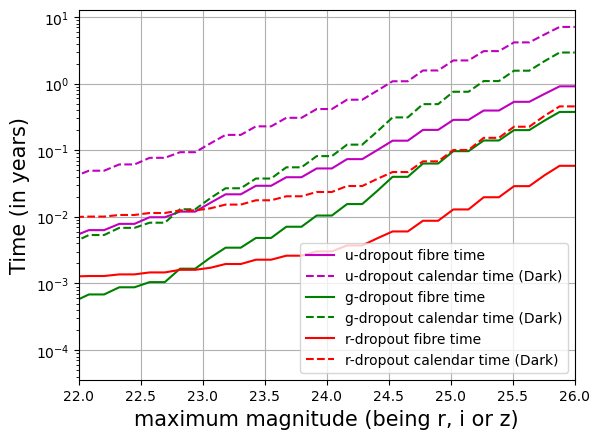

In [30]:
for i, band in enumerate(['u', 'g', 'r']):
    mask = results['band'] == band
    plt.plot(results['mag_max'][mask], results['fibre_time'][mask], label=f'{band}-dropout fibre time', color=color[i], )
    plt.plot(results['mag_max'][mask], results['calendar_time'][mask], '--', label=f'{band}-dropout calendar time (Dark)', color=color[i])
plt.ylabel('Time (in years)', fontsize=15)
plt.yscale('log')
plt.xlabel('maximum magnitude (being r, i or z)', fontsize=15)
plt.legend()
plt.grid(which='major')
plt.xlim(22, 26)
plt.savefig(f'../figures/LBG_survey_time.png', dpi = 300, bbox_inches='tight' )

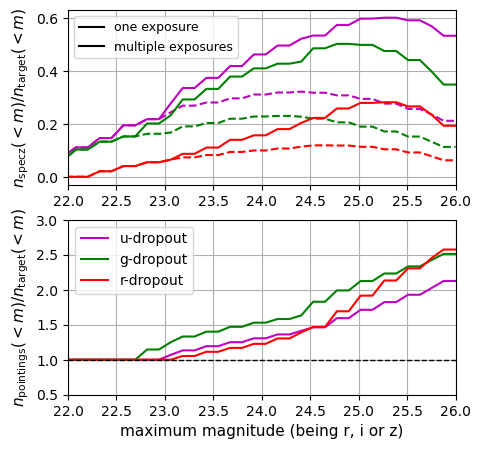

In [31]:
plt.figure(figsize=(5, 5))
plt.subplot(211)
for i, band in enumerate(['u', 'g', 'r']):
    mask = results['band'] == band

    plt.plot(results['mag_max'][mask], results['tracer_density_spec'][mask]/results['tracer_density'][mask], color=color[i], ls='-')
    plt.plot(results['mag_max'][mask], results['tracer_density_spec_one_exp'][mask]/results['tracer_density'][mask], color=color[i], ls='--')
    x = np.sum(samples[i]['object_count'], axis=0)*0.001

plt.ylabel(r'$n_{\rm specz}(<m)/n_{\rm target}(<m)$', fontsize=11)
plt.plot([], [], '-k', label = 'one exposure')
plt.plot([], [], '-k', label = 'multiple exposures')
plt.legend(loc='upper left', fontsize=9)
plt.grid(which='both')
#plt.yscale('log')
#plt.ylim(0., 1)
plt.xlim(22, 26)
plt.subplot(212)
for i, band in enumerate(['u', 'g', 'r']):
    mask = results['band'] == band
    plt.plot(results['mag_max'][mask], results['pass_density'][mask]/results['tracer_density'][mask], label=f'{band}-dropout', color=color[i],)

    #x = np.sum(samples[i]['object_count'], axis=0)*0.001
    #plt.plot(samples[i]['mag_center'], 3*x/x[-10], color=color[i],ls='-', lw=1)
plt.ylabel(r'$n_{\rm pointings}(<m)/n_{\rm target}(<m)$', fontsize=11)
plt.axhline(1,color='k', lw=1, ls='--')
plt.xlabel('maximum magnitude (being r, i or z)', fontsize=11)
plt.legend()
plt.ylim(0.5, 3)
plt.grid(which='both')
#plt.yscale('log')
plt.xlim(22, 26)
plt.savefig(f'../figures/LBG_survey_design.png', dpi = 300, bbox_inches='tight' )